In [1]:
!pip install -q torchvisionimport kagglehub

# Download latest version
path = kagglehub.dataset_download("aryansraut/preprocessed-ucf-crime-dataset-visual")

print("Path to dataset files:", path)

Mounting files to /kaggle/input/datasets/aryansraut/preprocessed-ucf-crime-dataset-visual...
Path to dataset files: /kaggle/input/datasets/aryansraut/preprocessed-ucf-crime-dataset-visual


In [2]:
!pip install -q torchvision

In [3]:
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models.video import swin3d_t
from PIL import Image
from tqdm import tqdm

In [4]:
class TikHarmVideoDataset(Dataset):
    def __init__(self, root_dir, split, transform=None):
        self.samples = []
        self.transform = transform
        
        classes = ["Adult Content", "Harmful Content", "Safe", "Suicide"]
        self.class_to_idx = {c: i for i, c in enumerate(classes)}

        for cls in classes:
            cls_path = os.path.join(root_dir, split, cls)
            for video_id in os.listdir(cls_path):
                self.samples.append(
                    (os.path.join(cls_path, video_id), self.class_to_idx[cls])
                )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        frame_dir, label = self.samples[idx]
        frames = sorted(os.listdir(frame_dir))[:16]

        imgs = []
        for f in frames:
            img = Image.open(os.path.join(frame_dir, f)).convert("RGB")
            if self.transform:
                img = self.transform(img)
            imgs.append(img)

        video = torch.stack(imgs)
        video = video.permute(1, 0, 2, 3)
        return video, label

In [5]:
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [17]:
root = "/kaggle/input/datasets/aryansraut/preprocessed-ucf-crime-dataset-visual/TikHarm_frames_16"

train_ds = TikHarmVideoDataset(root, "train", transform)
val_ds   = TikHarmVideoDataset(root, "val", transform)
test_ds  = TikHarmVideoDataset(root, "test", transform)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=4, pin_memory=True, persistent_workers=True)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True)
test_loader = DataLoader(test_ds, batch_size=8, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True)

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = swin3d_t(weights="DEFAULT")
model.head = nn.Linear(model.head.in_features, 4)

model = model.to(device)

if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)

In [20]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-5,
    weight_decay=0.05
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=20
)

In [21]:
def train_epoch(model, loader):
    model.train()
    total_loss = 0
    
    # Modern AMP syntax for PyTorch 2.0+
    scaler = torch.amp.GradScaler('cuda')
    
    for videos, labels in tqdm(loader, desc="Training"):
        videos = videos.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        
        optimizer.zero_grad()
        
        # Modern autocast syntax
        with torch.amp.autocast('cuda'):
            outputs = model(videos)
            loss = criterion(outputs, labels)
        
        scaler.scale(loss).backward()
        
        # Gradient clipping with scaled gradients
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        scaler.step(optimizer)
        scaler.update()
        
        total_loss += loss.item()
        
    return total_loss / len(loader)

In [22]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

def evaluate(model, loader, return_details=False):
    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for videos, labels in loader:
            videos = videos.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            
            outputs = model(videos)
            _, preds = torch.max(outputs, 1)
            
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
            if return_details:
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
    
    accuracy = correct / total
    
    if return_details:
        return accuracy, all_preds, all_labels
    return accuracy

In [23]:
best_val_acc = 0
patience = 5
patience_counter = 0
train_losses = []
val_accs = []

class_names = ["Adult Content", "Harmful Content", "Safe", "Suicide"]

for epoch in range(20):
    # Training
    train_loss = train_epoch(model, train_loader)
    train_losses.append(train_loss)
    
    # Validation with details
    val_acc, val_preds, val_labels = evaluate(model, val_loader, return_details=True)
    val_accs.append(val_acc)
    
    # Learning rate scheduling
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    
    # Per-class metrics every 5 epochs
    if (epoch + 1) % 5 == 0:
        print("\n" + "="*50)
        print(f"Epoch {epoch+1} Detailed Metrics:")
        print(classification_report(val_labels, val_preds, 
                                  target_names=class_names, digits=3))
    
    print(f"\nEpoch {epoch+1}/20")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Accuracy: {val_acc:.4f}")
    print(f"Learning Rate: {current_lr:.2e}")
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        
        # Save checkpoint
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'val_acc': val_acc,
            'train_loss': train_loss,
        }
        torch.save(checkpoint, "best_swin3d_tikharm.pt")
        print(f"✓ New best model saved! (Val Acc: {val_acc:.4f})")
    else:
        patience_counter += 1
        
    # Early stopping
    if patience_counter >= patience:
        print(f"\nEarly stopping triggered after {epoch+1} epochs")
        break

print(f"\nTraining completed. Best validation accuracy: {best_val_acc:.4f}")

Training: 100%|██████████| 346/346 [02:45<00:00,  2.09it/s]



Epoch 1/20
Train Loss: 0.8104
Val Accuracy: 0.8030
Learning Rate: 2.98e-05
✓ New best model saved! (Val Acc: 0.8030)


Training: 100%|██████████| 346/346 [02:43<00:00,  2.12it/s]



Epoch 2/20
Train Loss: 0.6355
Val Accuracy: 0.8485
Learning Rate: 2.93e-05
✓ New best model saved! (Val Acc: 0.8485)


Training: 100%|██████████| 346/346 [02:43<00:00,  2.11it/s]


...


Epoch 16/20
Train Loss: 0.3732
Val Accuracy: 0.8687
Learning Rate: 2.86e-06


Training: 100%|██████████| 346/346 [02:42<00:00,  2.12it/s]



Epoch 17/20
Train Loss: 0.3733
Val Accuracy: 0.8662
Learning Rate: 1.63e-06


Training: 100%|██████████| 346/346 [02:42<00:00,  2.12it/s]



Epoch 18/20
Train Loss: 0.3688
Val Accuracy: 0.8737
Learning Rate: 7.34e-07

Early stopping triggered after 18 epochs

Training completed. Best validation accuracy: 0.8864


TEST SET EVALUATION
Overall Test Accuracy: 0.8671

Per-Class Performance:
                 precision    recall  f1-score   support

  Adult Content     0.8718    0.8718    0.8718       195
Harmful Content     0.8844    0.7727    0.8248       198
           Safe     0.8889    0.8800    0.8844       200
        Suicide     0.8304    0.9442    0.8836       197

       accuracy                         0.8671       790
      macro avg     0.8689    0.8672    0.8662       790
   weighted avg     0.8689    0.8671    0.8662       790


Confusion Matrix:
Rows: True, Columns: Predicted
         AC     HC    Safe  Suicide
Adult Co [170  11   6   8]
Harmful  [ 16 153  11  18]
Safe     [  5   7 176  12]
Suicide  [  4   2   5 186]


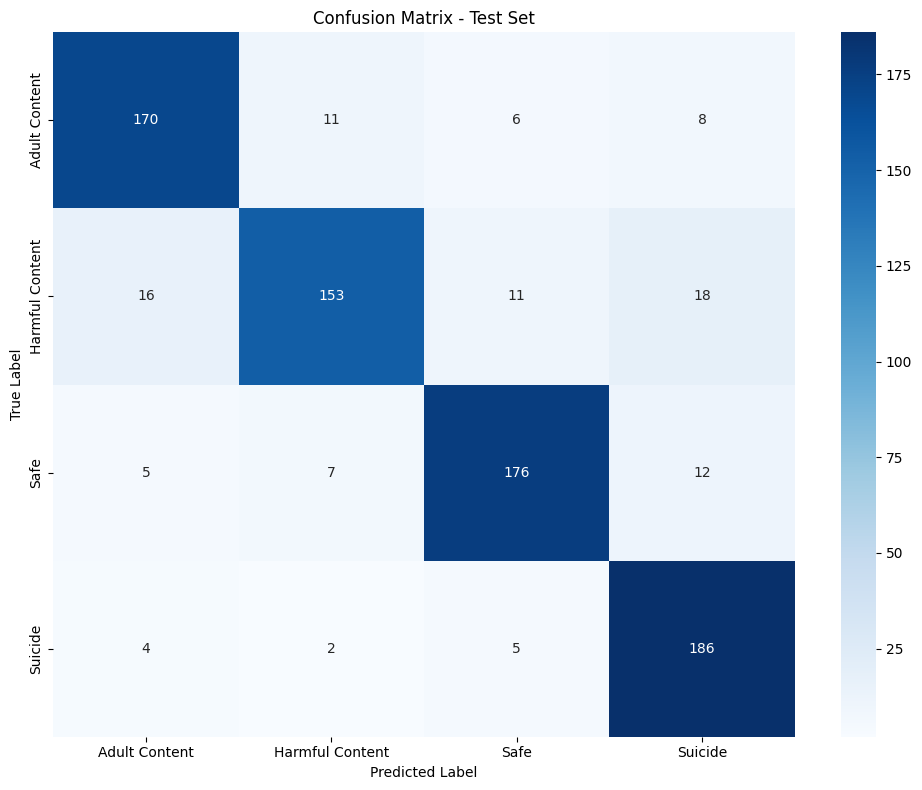

In [24]:
# Load best model
checkpoint = torch.load("best_swin3d_tikharm.pt")

best_model = swin3d_t(weights=None)
best_model.head = nn.Linear(best_model.head.in_features, 4)

if isinstance(checkpoint['model_state_dict'], dict):
    best_model.load_state_dict(checkpoint['model_state_dict'])
else:
    best_model.load_state_dict(checkpoint['model_state_dict'])

best_model = best_model.to(device)

# Detailed test evaluation
test_acc, test_preds, test_labels = evaluate(best_model, test_loader, return_details=True)

print("TEST SET EVALUATION")
print(f"Overall Test Accuracy: {test_acc:.4f}")

print("\nPer-Class Performance:")
print(classification_report(test_labels, test_preds, 
                          target_names=class_names, digits=4))

print("\nConfusion Matrix:")
cm = confusion_matrix(test_labels, test_preds)
print("Rows: True, Columns: Predicted")
print("         AC     HC    Safe  Suicide")
for i, row in enumerate(cm):
    print(f"{class_names[i][:8]:8} {row}")

# Visualize confusion matrix (optional)
try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix - Test Set')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig('confusion_matrix.png')
    plt.show()
except:
    pass